## Customer Segmentation Project
- 

- Mall Customers dataset
- we will implement K means clustering to check the spending patterns of our customers
- segment the customer spending behaviour

Task:
1. data ingestion/acquisition
2. Data EDA
3. Preprocessing, if needed
4. train a model
5. Cluster the users

Optional
6. Tag each cluster with a name and save that column in dataframe

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

In [3]:
url = "https://raw.githubusercontent.com/tirthajyoti/Machine-Learning-with-Python/master/Datasets/Mall_Customers.csv"

df = pd.read_csv(url)
display(df.head())
df.info()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   CustomerID              200 non-null    int64
 1   Gender                  200 non-null    str  
 2   Age                     200 non-null    int64
 3   Annual Income (k$)      200 non-null    int64
 4   Spending Score (1-100)  200 non-null    int64
dtypes: int64(4), str(1)
memory usage: 7.9 KB


In [12]:
df = df.drop(columns= ['CustomerID', 'Gender'])

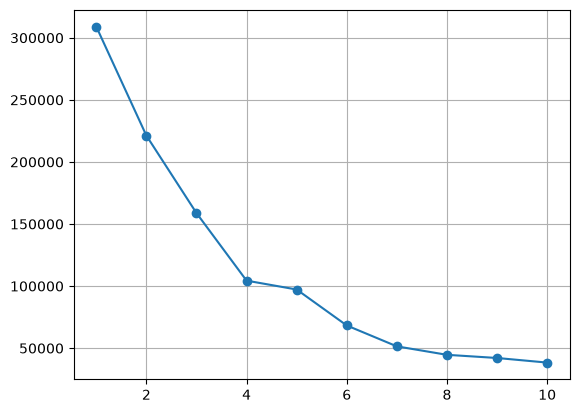

In [14]:
errors = []

for k in range(1, 11):
    model = KMeans(n_clusters= k, random_state= 42)
    model.fit(df)
    errors.append(model.inertia_)

plt.plot(range(1, 11), errors, marker= 'o')
plt.grid()
plt.show()

In [21]:
model_choice = KMeans(n_clusters= 5, init= 'random', random_state= 42)

df['KClustering'] = model_choice.fit_predict(df)
df.sample(10)

,Age,Annual Income (k$),Spending Score (1-100),KClustering
35,21,33,81,1
45,24,39,65,1
159,30,78,73,4
27,35,28,61,1
13,24,20,77,1
16,35,21,35,0
18,52,23,29,0
149,34,78,90,4
55,47,43,41,3
186,54,101,24,2


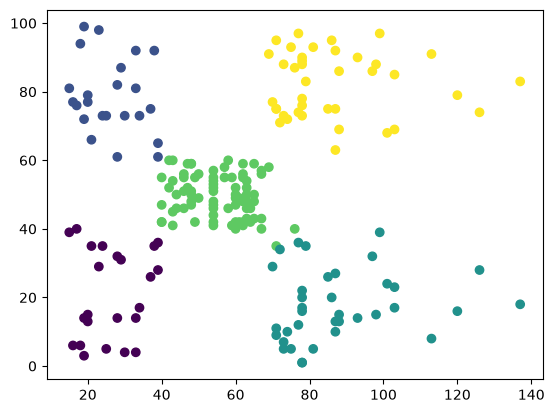

In [ ]:
plt.scatter(df['Annual Income (k$)'], df['Spending Score (1-100)'], c= df['KClustering'])
plt.show()
